# Home Cage 2-Minute Bout Mean DA

This notebook mirrors the Hab/Dishab bout mean DA workflow, but limits each Home Cage agent bout to the first 120 seconds so mPFC and NAc can be compared on the same scale.

In [1]:
import os
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = Path(os.getcwd()).resolve().parent
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / 'Home_Cage'))

from experiment_class import Experiment
from bouts_extension import plot_behavior_across_bouts_no_identities


In [2]:
REGION_CONFIGS = {
    'mPFC': {
        'experiment_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\mpfc",
        'csv_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\mpfc_csvs",
        'color': '#FFAF00',
        'ylim': (-3, 3),
    },
    'NAc': {
        'experiment_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac",
        'csv_path': r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac_csvs",
        'color': '#15616F',
        'ylim': (-3, 3),
    },
}

SELECTED_REGIONS = ['NAc', 'mPFC']
BOUT_DEFINITIONS = [
    {'prefix': 'Short_Term', 'introduced': 'Short_Term_Introduced', 'removed': 'Short_Term_Removed'},
    {'prefix': 'Long_Term', 'introduced': 'Long_Term_Introduced', 'removed': 'Long_Term_Removed'},
    {'prefix': 'Novel', 'introduced': 'Novel_Introduced', 'removed': 'Novel_Removed'},
]
BOUT_ORDER = ['Short_Term-1', 'Short_Term-2', 'Long_Term-1', 'Novel-1']
WINDOW_ORDER = ['full_bout', 'investigation', 'non_investigation']
WINDOW_LABELS = {
    'full_bout': 'Full Bout Mean (First 2 min)',
    'investigation': 'Investigation Mean (First 2 min)',
    'non_investigation': 'Non-Investigation Mean (First 2 min)',
}
XTICK_LABELS = ['Acq-ST', 'Short-T', 'Long-T', 'Novel']
XTICK_COLORS = ['#2A9D8F', '#457B9D', '#7B2CBF', '#E76F51']
SIGNAL_NAME = 'zscore'
SIGNAL_COLUMN = 'Mean Z-score'
WINDOW_CAP_S = 120
YTICKS_INCREMENT = 1

OUTPUT_DIR = PROJECT_ROOT / 'Home_Cage' / 'hc_bout_mean_da_2min_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

WindowsPath('C:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Home_Cage/hc_bout_mean_da_2min_outputs')

In [ ]:
ANALYSIS_ORDER = ['first_2min', 'full_bout', 'first_investigation']
ANALYSIS_LABELS = {
    'first_2min': 'First 2 min',
    'full_bout': 'Full Bout',
    'first_investigation': 'First Investigation Instance',
}

BEHAVIOR_ORDER = ['full_bout', 'investigation', 'non_investigation']
BEHAVIOR_LABELS = {
    'full_bout': 'Full Bout Mean',
    'investigation': 'Investigation Mean',
    'non_investigation': 'Non-Investigation Mean',
}

In [ ]:
def load_region_experiment(region_name):
    config = REGION_CONFIGS[region_name]
    exp = Experiment(config['experiment_path'], config['csv_path'])
    exp.default_batch_process()
    exp.group_extract_manual_annotations(BOUT_DEFINITIONS, first_only=False)
    return exp


def get_signal_array(trial, signal_name='zscore'):
    if not hasattr(trial, signal_name):
        raise AttributeError(f"Trial does not have signal '{signal_name}'")
    return np.asarray(getattr(trial, signal_name), dtype=float)


def merge_intervals(intervals):
    cleaned = sorted(
        (float(start), float(end))
        for start, end in intervals
        if pd.notna(start) and pd.notna(end) and float(end) > float(start)
    )
    if not cleaned:
        return []

    merged = [cleaned[0]]
    for start, end in cleaned[1:]:
        last_start, last_end = merged[-1]
        if start <= last_end:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    return merged


def clip_intervals_to_bounds(intervals, start_bound, end_bound):
    clipped = []
    for start, end in intervals:
        start = max(float(start), float(start_bound))
        end = min(float(end), float(end_bound))
        if end > start:
            clipped.append((start, end))
    return merge_intervals(clipped)


def subtract_intervals(base_interval, intervals):
    base_start, base_end = map(float, base_interval)
    remaining = [(base_start, base_end)]

    for cut_start, cut_end in merge_intervals(intervals):
        updated = []
        for seg_start, seg_end in remaining:
            if cut_end <= seg_start or cut_start >= seg_end:
                updated.append((seg_start, seg_end))
                continue
            if cut_start > seg_start:
                updated.append((seg_start, cut_start))
            if cut_end < seg_end:
                updated.append((cut_end, seg_end))
        remaining = updated

    return [(start, end) for start, end in remaining if end > start]


def intervals_mean(timestamps, signal, intervals):
    pooled = []
    total_n = 0

    for start, end in intervals:
        mask = (timestamps >= float(start)) & (timestamps <= float(end))
        values = signal[mask]
        values = values[~np.isnan(values)]
        if values.size == 0:
            continue
        pooled.append(values)
        total_n += int(values.size)

    if not pooled:
        return np.nan, 0

    pooled = np.concatenate(pooled)
    return float(np.nanmean(pooled)), total_n


def first_interval_only(intervals):
    merged = merge_intervals(intervals)
    if not merged:
        return []
    return [merged[0]]


def compute_auto_ylim(pivot_df, pad=0.2, min_range=1.0):
    values = pivot_df.to_numpy(dtype=float).ravel()
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return (-1, 1)

    ymin = float(values.min())
    ymax = float(values.max())

    if ymin == ymax:
        half = max(abs(ymin) * 0.25, min_range / 2)
        return (ymin - half, ymax + half)

    yrange = ymax - ymin
    pad_amt = max(yrange * pad, 0.1)
    ymin -= pad_amt
    ymax += pad_amt

    center_zero = max(abs(ymin), abs(ymax))
    return (-center_zero, center_zero)


MANUAL_YLIMS = {
    # ('NAc', 'first_investigation', 'investigation'): (-2, 3),
}


def get_region_color(region_name):
    return REGION_CONFIGS.get(region_name, {'color': '#4C4C4C'})['color']


def get_region_ylim(region_name):
    return REGION_CONFIGS.get(region_name, {'ylim': (-3, 3)})['ylim']


def resolve_ylim(region_name, analysis_name=None, behavior_name=None, pivot_df=None, auto_ylim=True):
    key = (region_name, analysis_name, behavior_name)

    if key in MANUAL_YLIMS:
        return MANUAL_YLIMS[key]

    if auto_ylim and pivot_df is not None:
        return compute_auto_ylim(pivot_df)

    return get_region_ylim(region_name)


def build_manual_investigation_metadata(region_names, signal_name='zscore', max_window_s=120):
    rows = []
    notes = []

    for region_name in region_names:
        exp = load_region_experiment(region_name)

        for trial_name, trial in exp.trials.items():
            timestamps = np.asarray(trial.timestamps, dtype=float)
            signal = get_signal_array(trial, signal_name=signal_name)
            behaviors = trial.behaviors.copy()

            for bout_label, (bout_start, bout_end) in trial.bouts.items():
                if bout_label not in BOUT_ORDER:
                    continue

                bout_start = float(bout_start)
                bout_end = float(bout_end)
                capped_end = min(bout_end, bout_start + float(max_window_s))

                raw_inv = behaviors[
                    (behaviors['Bout'] == bout_label) & (behaviors['Behavior'] == 'Investigation')
                ].copy()

                raw_intervals = list(zip(raw_inv['Event_Start'], raw_inv['Event_End']))
                full_bout_intervals = [(bout_start, bout_end)] if bout_end > bout_start else []
                first_2min_intervals = [(bout_start, capped_end)] if capped_end > bout_start else []
                first_investigation_intervals = first_interval_only(
                    clip_intervals_to_bounds(raw_intervals, bout_start, bout_end)
                )

                notes.append(
                    {
                        'BrainRegion': region_name,
                        'trial_name': trial_name,
                        'Subject': trial.subject_name,
                        'Bout': bout_label,
                        'FirstInvestigationFound': len(first_investigation_intervals) > 0,
                        'FirstInvestigationStart_s': first_investigation_intervals[0][0] if first_investigation_intervals else np.nan,
                        'FirstInvestigationEnd_s': first_investigation_intervals[0][1] if first_investigation_intervals else np.nan,
                        'FirstInvestigationDuration_s': (
                            first_investigation_intervals[0][1] - first_investigation_intervals[0][0]
                            if first_investigation_intervals else np.nan
                        ),
                    }
                )

                analysis_interval_map = {
                    'first_2min': first_2min_intervals,
                    'full_bout': full_bout_intervals,
                    'first_investigation': first_investigation_intervals,
                }

                for analysis_name, analysis_intervals in analysis_interval_map.items():
                    if analysis_name == 'first_investigation':
                        investigation_intervals = analysis_intervals
                        full_intervals = analysis_intervals
                    else:
                        full_intervals = analysis_intervals
                        investigation_intervals = clip_intervals_to_bounds(raw_intervals, bout_start, full_intervals[0][1]) if full_intervals else []

                    non_investigation_intervals = []
                    for interval in full_intervals:
                        non_investigation_intervals.extend(
                            subtract_intervals(interval, investigation_intervals)
                        )

                    window_intervals = {
                        'full_bout': full_intervals,
                        'investigation': investigation_intervals,
                        'non_investigation': non_investigation_intervals,
                    }

                    for behavior_name in BEHAVIOR_ORDER:
                        intervals = window_intervals[behavior_name]
                        mean_signal, n_samples = intervals_mean(timestamps, signal, intervals)

                        rows.append(
                            {
                                'BrainRegion': region_name,
                                'trial_name': trial_name,
                                'Subject': trial.subject_name,
                                'Bout': bout_label,
                                'Analysis': analysis_name,
                                'AnalysisLabel': ANALYSIS_LABELS[analysis_name],
                                'Behavior': behavior_name,
                                'BehaviorLabel': BEHAVIOR_LABELS[behavior_name],
                                SIGNAL_COLUMN: mean_signal,
                                'N_Samples': n_samples,
                                'Window_Duration_s': float(sum(end - start for start, end in intervals)),
                                'SignalName': signal_name,
                            }
                        )

    metadata_df = pd.DataFrame(rows)
    metadata_df['Bout'] = pd.Categorical(metadata_df['Bout'], categories=BOUT_ORDER, ordered=True)
    metadata_df['Analysis'] = pd.Categorical(metadata_df['Analysis'], categories=ANALYSIS_ORDER, ordered=True)
    metadata_df['Behavior'] = pd.Categorical(metadata_df['Behavior'], categories=BEHAVIOR_ORDER, ordered=True)
    metadata_df = metadata_df.sort_values(['BrainRegion', 'Analysis', 'Behavior', 'Bout', 'Subject']).reset_index(drop=True)

    notes_df = pd.DataFrame(notes).sort_values(['BrainRegion', 'Bout', 'Subject']).reset_index(drop=True)
    return metadata_df, notes_df


def get_plot_pivot(metadata_df, region_name, analysis_name, behavior_name):
    plot_df = metadata_df[
        (metadata_df['BrainRegion'] == region_name)
        & (metadata_df['Analysis'] == analysis_name)
        & (metadata_df['Behavior'] == behavior_name)
    ].copy()
    return plot_df.pivot(index='Subject', columns='Bout', values=SIGNAL_COLUMN).reindex(columns=BOUT_ORDER)


def plot_single_analysis(metadata_df, region_name, analysis_name, behavior_name='investigation', auto_ylim=True):
    subset = metadata_df[
        (metadata_df['BrainRegion'] == region_name)
        & (metadata_df['Analysis'] == analysis_name)
    ].copy()

    pivot_df = get_plot_pivot(metadata_df, region_name, analysis_name, behavior_name)
    ylim = resolve_ylim(
        region_name,
        analysis_name=analysis_name,
        behavior_name=behavior_name,
        pivot_df=pivot_df,
        auto_ylim=auto_ylim,
    )

    return plot_behavior_across_bouts_no_identities(
        metadata_df=subset,
        y_col=SIGNAL_COLUMN,
        behavior=behavior_name,
        title=f'{region_name} | {BEHAVIOR_LABELS[behavior_name]} | {ANALYSIS_LABELS[analysis_name]}',
        xlabel='Agent',
        ylabel='Mean z-scored dF/F',
        custom_xtick_labels=XTICK_LABELS,
        custom_xtick_colors=XTICK_COLORS,
        ylim=ylim,
        bar_color=get_region_color(region_name),
        yticks_increment=YTICKS_INCREMENT,
        figsize=(12, 7),
        pad_inches=0.1,
        save=False,
    )


def draw_analysis_panel(ax, metadata_df, region_name, analysis_name, behavior_name='investigation', auto_ylim=True):
    pivot_df = get_plot_pivot(metadata_df, region_name, analysis_name, behavior_name)
    x = np.arange(len(BOUT_ORDER))
    color = get_region_color(region_name)

    mean_values = pivot_df.mean()
    sem_values = pivot_df.sem()

    ax.bar(
        x,
        mean_values.values,
        yerr=sem_values.values,
        width=0.68,
        color=color,
        edgecolor='black',
        linewidth=2.5,
        capsize=5,
        error_kw=dict(elinewidth=2.0, capthick=2.0),
        alpha=0.9,
        zorder=3,
    )

    for _, row in pivot_df.iterrows():
        y = row.values.astype(float)
        ax.plot(x, y, color=color, alpha=0.18, linewidth=1.6, zorder=1)
        ax.scatter(x, y, facecolors='white', edgecolors=color, s=45, alpha=0.75, linewidth=1.2, zorder=2)

    ax.set_title(ANALYSIS_LABELS[analysis_name], fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(XTICK_LABELS, fontsize=16)
    for tick, tick_color in zip(ax.get_xticklabels(), XTICK_COLORS):
        tick.set_color(tick_color)

    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, zorder=0)

    ylim = resolve_ylim(
        region_name,
        analysis_name=analysis_name,
        behavior_name=behavior_name,
        pivot_df=pivot_df,
        auto_ylim=auto_ylim,
    )
    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(np.floor(ylim[0]), np.ceil(ylim[1]) + YTICKS_INCREMENT, YTICKS_INCREMENT))

    ax.tick_params(axis='y', labelsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2.5)
    ax.spines['bottom'].set_linewidth(2.5)


def plot_all_three_analyses(metadata_df, region_name, behavior_name='investigation', auto_ylim=True):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

    for ax, analysis_name in zip(axes, ANALYSIS_ORDER):
        draw_analysis_panel(
            ax,
            metadata_df,
            region_name,
            analysis_name,
            behavior_name=behavior_name,
            auto_ylim=auto_ylim,
        )
        ax.set_xlabel('Agent', fontsize=16)

    axes[0].set_ylabel('Mean z-scored dF/F', fontsize=18)
    fig.suptitle(f'{region_name} | {BEHAVIOR_LABELS[behavior_name]}', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

def compute_auto_ylim_from_values(values, pad=0.2, min_range=1.0, center_zero=True):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if values.size == 0:
        return (-1, 1)

    ymin = float(values.min())
    ymax = float(values.max())

    if ymin == ymax:
        half = max(abs(ymin) * 0.25, min_range / 2)
        ymin -= half
        ymax += half
    else:
        yrange = ymax - ymin
        pad_amt = max(yrange * pad, 0.1)
        ymin -= pad_amt
        ymax += pad_amt

    if center_zero:
        bound = max(abs(ymin), abs(ymax))
        return (-bound, bound)

    return (ymin, ymax)


def resolve_ylim(region_name=None, window_name=None, values=None, auto_ylim=False, comparison=False):
    if comparison:
        key = ('comparison', window_name)
        if key in MANUAL_YLIMS:
            return MANUAL_YLIMS[key]
        if auto_ylim and values is not None:
            return compute_auto_ylim_from_values(values)
        return DEFAULT_COMPARISON_YLIM

    key = (region_name, window_name)
    if key in MANUAL_YLIMS:
        return MANUAL_YLIMS[key]
    if auto_ylim and values is not None:
        return compute_auto_ylim_from_values(values)
    return REGION_CONFIGS.get(region_name, {}).get('ylim', (-3, 3))

In [5]:
metadata_df, first_investigation_notes_df = build_manual_investigation_metadata(
    SELECTED_REGIONS,
    signal_name=SIGNAL_NAME,
    max_window_s=WINDOW_CAP_S,
)

display(first_investigation_notes_df.head())
display(metadata_df.head())

Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n5-240823-085032\Notes.txt
read from t=0s to t=1789.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n6-240823-101436\Notes.txt
read from t=0s to t=1793.07s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n7-240824-062103\Notes.txt
read from t=0s to t=1803.56s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn1-250120-063024\Notes.txt
read from t=0s to t=1833.87s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn2-250120-072910\Notes.txt
read from t=0s to t=1774.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn3-250121-074834\Notes.txt
read f

,BrainRegion,trial_name,Subject,Bout,FirstInvestigationFound,FirstInvestigationStart_s,FirstInvestigationEnd_s,FirstInvestigationDuration_s
0,NAc,n5-240823-085032,n5,Long_Term-1,True,1471.3,1479.7,8.4
1,NAc,n6-240823-101436,n6,Long_Term-1,True,935.4,937.3,1.9
2,NAc,n7-240824-062103,n7,Long_Term-1,True,1167.3,1169.6,2.3
3,NAc,nn1-250120-063024,nn1,Long_Term-1,True,1471.1,1473.2,2.1
4,NAc,nn2-250120-072910,nn2,Long_Term-1,True,1170.1,1170.6,0.5


,BrainRegion,trial_name,Subject,Bout,Analysis,AnalysisLabel,Behavior,BehaviorLabel,Mean Z-score,N_Samples,Window_Duration_s,SignalName
0,NAc,n5-240823-085032,n5,Short_Term-1,first_2min,First 2 min,full_bout,Full Bout Mean,1.577465,12001,120.0,zscore
1,NAc,n6-240823-101436,n6,Short_Term-1,first_2min,First 2 min,full_bout,Full Bout Mean,0.470093,12001,120.0,zscore
2,NAc,n7-240824-062103,n7,Short_Term-1,first_2min,First 2 min,full_bout,Full Bout Mean,0.143542,12001,120.0,zscore
3,NAc,nn1-250120-063024,nn1,Short_Term-1,first_2min,First 2 min,full_bout,Full Bout Mean,0.411358,12001,120.0,zscore
4,NAc,nn2-250120-072910,nn2,Short_Term-1,first_2min,First 2 min,full_bout,Full Bout Mean,-0.014018,12001,120.0,zscore


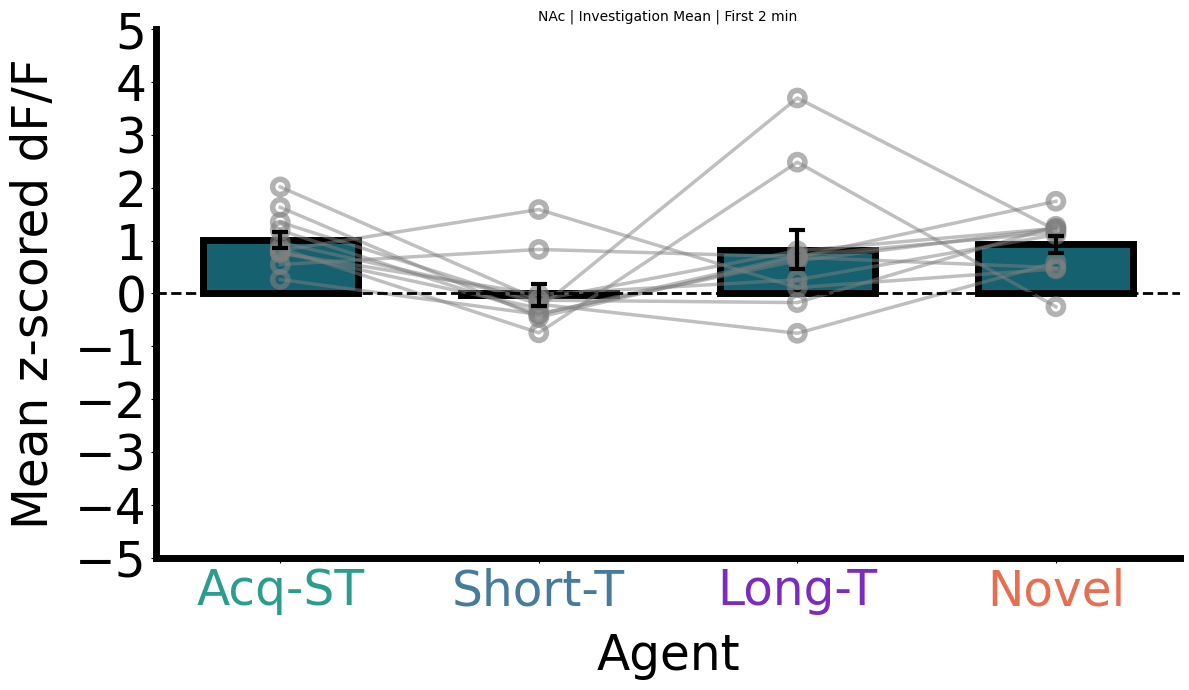


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  3.7719   0.0037   1.1373
 Short_Term-1 vs Long_Term-1 11  0.4313   0.6754   0.1300
     Short_Term-1 vs Novel-1 11  0.3576   0.7281   0.1078
 Short_Term-2 vs Long_Term-1 11 -1.7976   0.1025  -0.5420
     Short_Term-2 vs Novel-1 11 -4.0945   0.0022  -1.2345
      Long_Term-1 vs Novel-1 11 -0.2300   0.8227  -0.0693


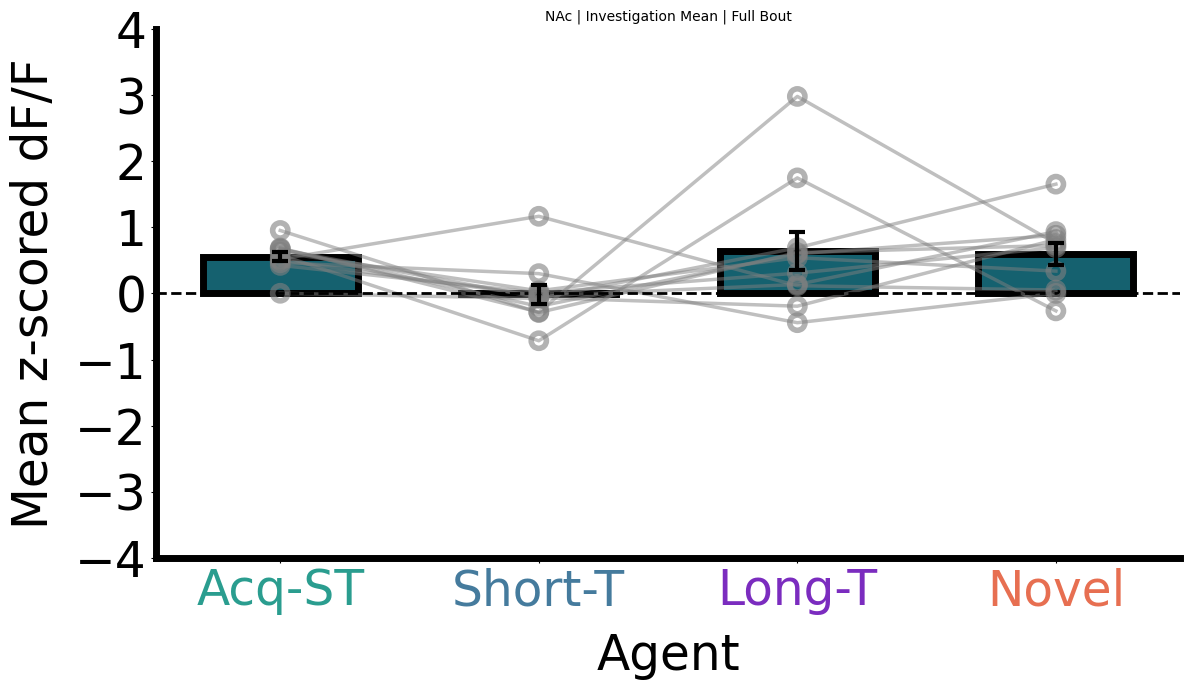


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  3.3394   0.0075   1.0069
 Short_Term-1 vs Long_Term-1 11 -0.3193   0.7561  -0.0963
     Short_Term-1 vs Novel-1 11 -0.2234   0.8278  -0.0673
 Short_Term-2 vs Long_Term-1 11 -1.7256   0.1151  -0.5203
     Short_Term-2 vs Novel-1 11 -2.6288   0.0252  -0.7926
      Long_Term-1 vs Novel-1 11  0.1423   0.8896   0.0429


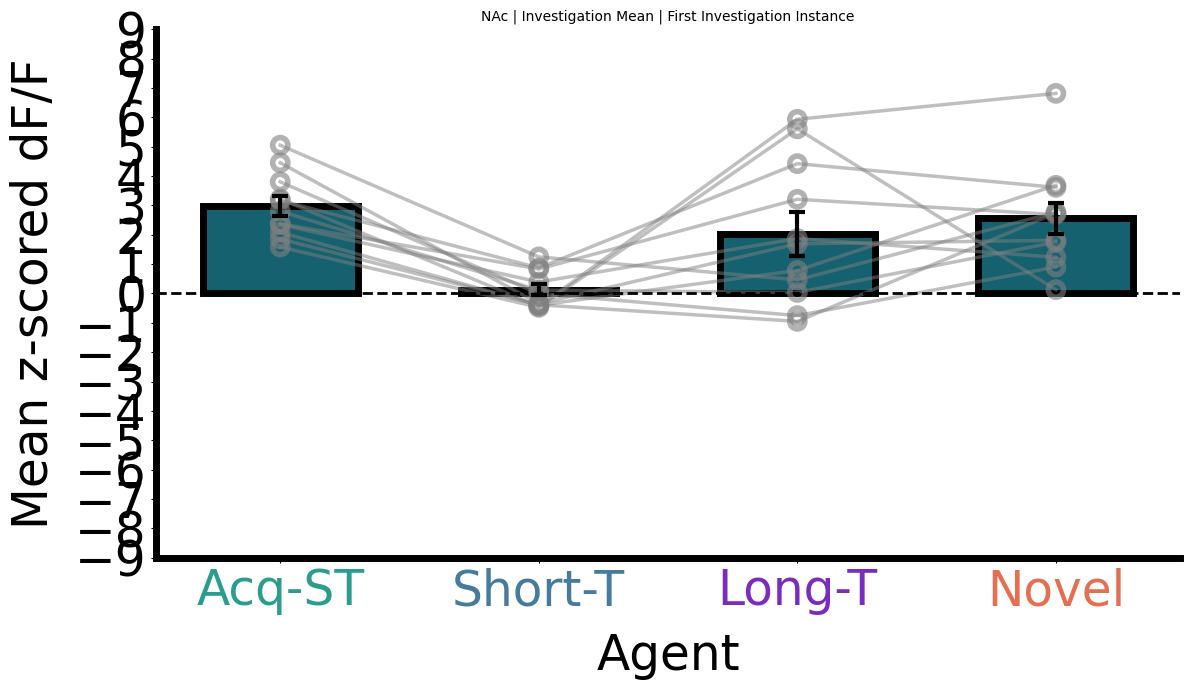


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  9.3320   0.0000   2.8137
 Short_Term-1 vs Long_Term-1 11  1.0925   0.3002   0.3294
     Short_Term-1 vs Novel-1 11  0.6973   0.5015   0.2103
 Short_Term-2 vs Long_Term-1 11 -2.4658   0.0333  -0.7435
     Short_Term-2 vs Novel-1 11 -4.2103   0.0018  -1.2694
      Long_Term-1 vs Novel-1 11 -0.7042   0.4974  -0.2123


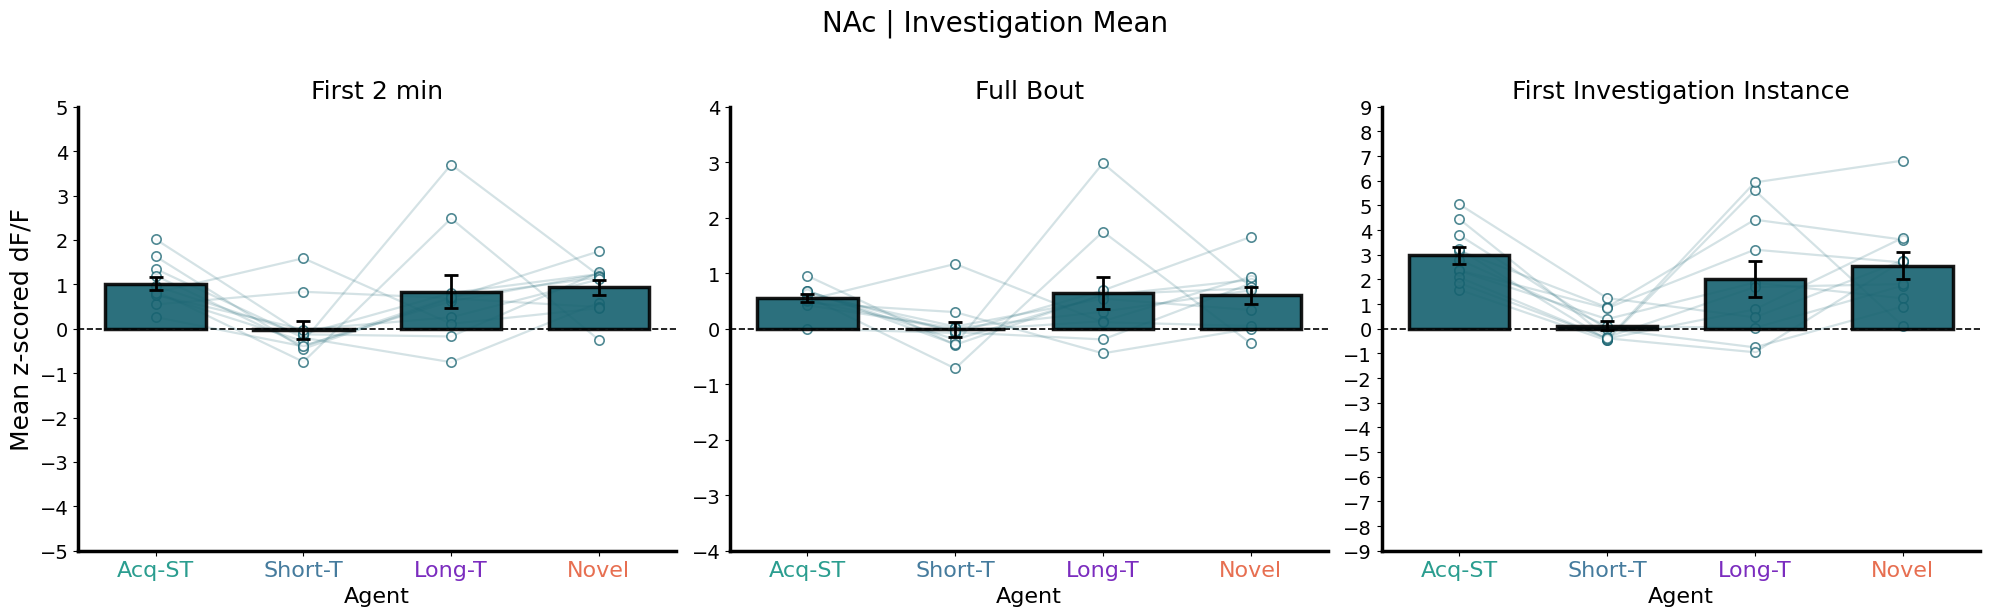

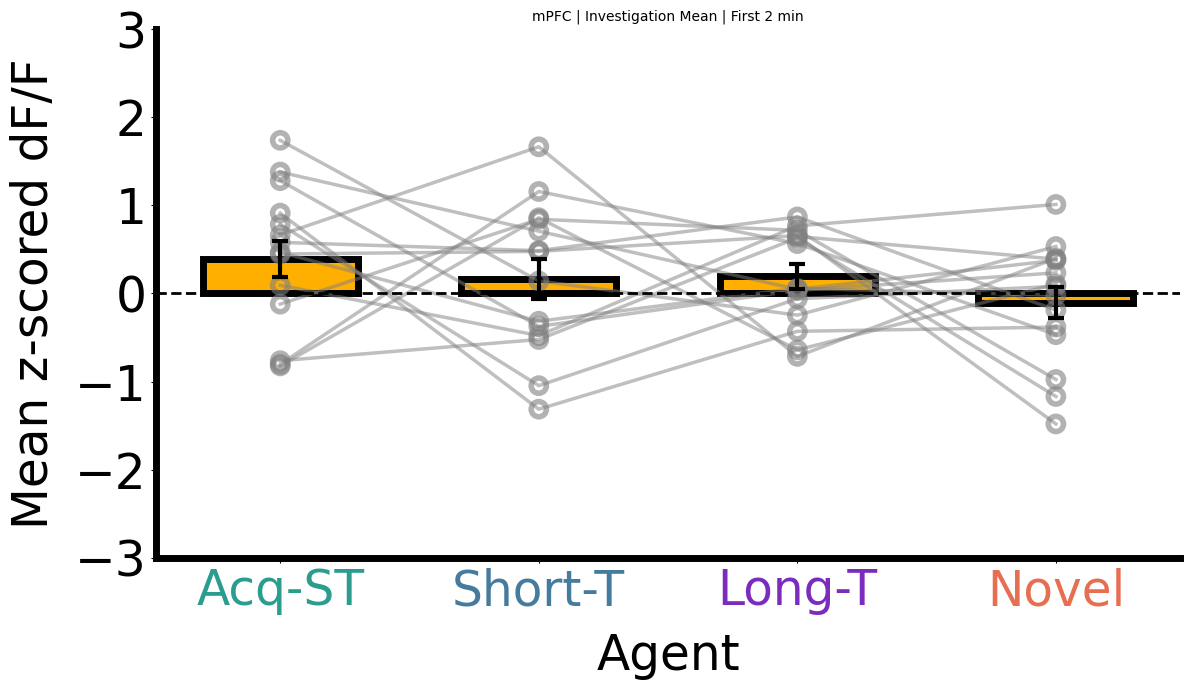


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  0.7169   0.4861   0.1916
 Short_Term-1 vs Long_Term-1 15  0.7042   0.4928   0.1818
     Short_Term-1 vs Novel-1 15  2.3341   0.0350   0.6027
 Short_Term-2 vs Long_Term-1 14  0.0082   0.9936   0.0022
     Short_Term-2 vs Novel-1 14  1.0001   0.3355   0.2673
      Long_Term-1 vs Novel-1 15  1.1410   0.2730   0.2946


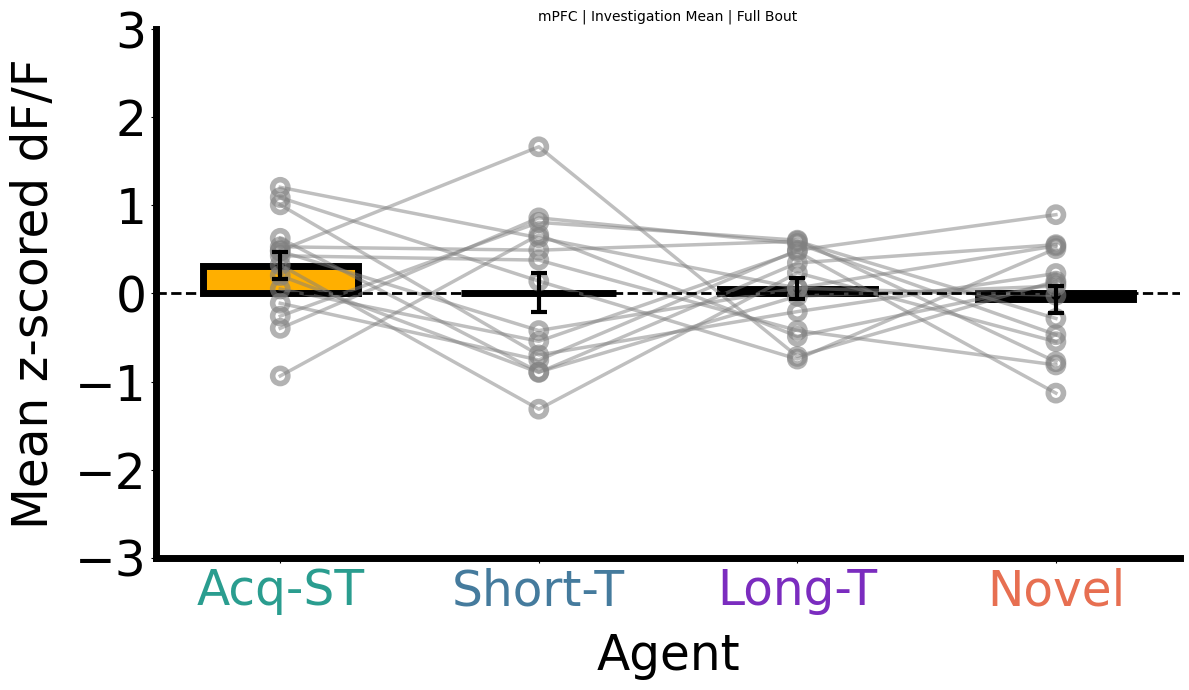


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 15  1.0753   0.3004   0.2776
 Short_Term-1 vs Long_Term-1 15  1.1709   0.2612   0.3023
     Short_Term-1 vs Novel-1 15  2.1201   0.0523   0.5474
 Short_Term-2 vs Long_Term-1 15 -0.1686   0.8685  -0.0435
     Short_Term-2 vs Novel-1 15  0.2585   0.7998   0.0667
      Long_Term-1 vs Novel-1 15  0.5462   0.5935   0.1410


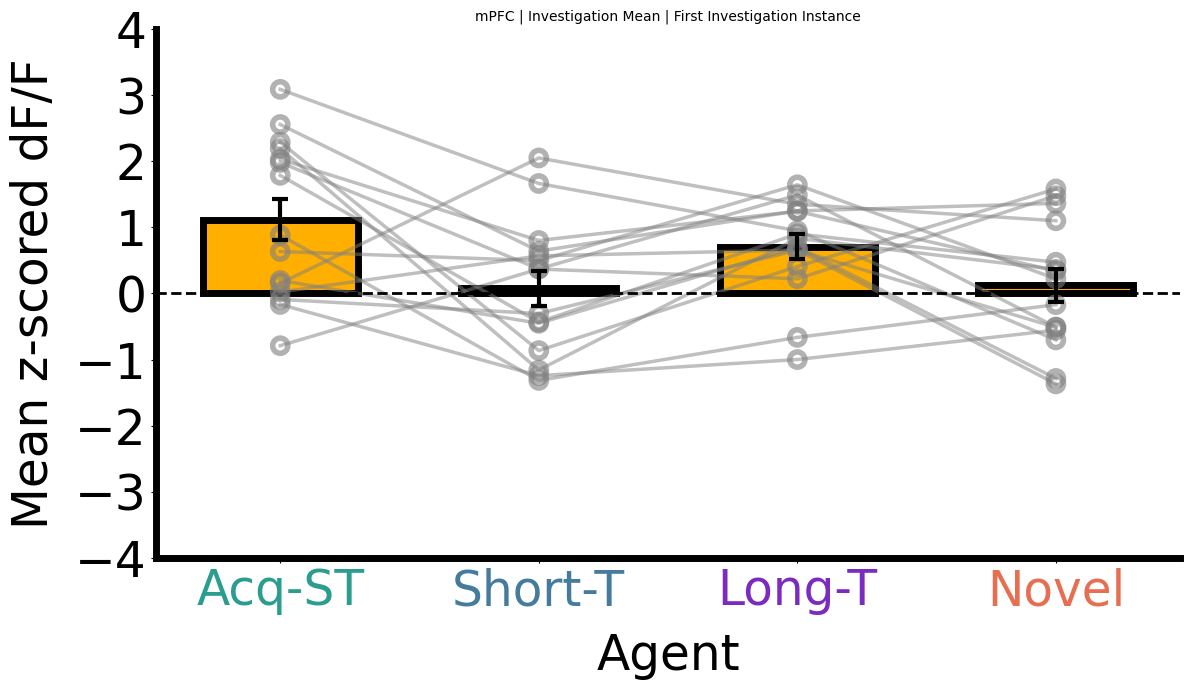


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 15  2.6835   0.0178   0.6929
 Short_Term-1 vs Long_Term-1 15  1.3738   0.1911   0.3547
     Short_Term-1 vs Novel-1 15  2.7633   0.0152   0.7135
 Short_Term-2 vs Long_Term-1 15 -3.1657   0.0069  -0.8174
     Short_Term-2 vs Novel-1 15 -0.1226   0.9042  -0.0317
      Long_Term-1 vs Novel-1 15  2.0265   0.0622   0.5232


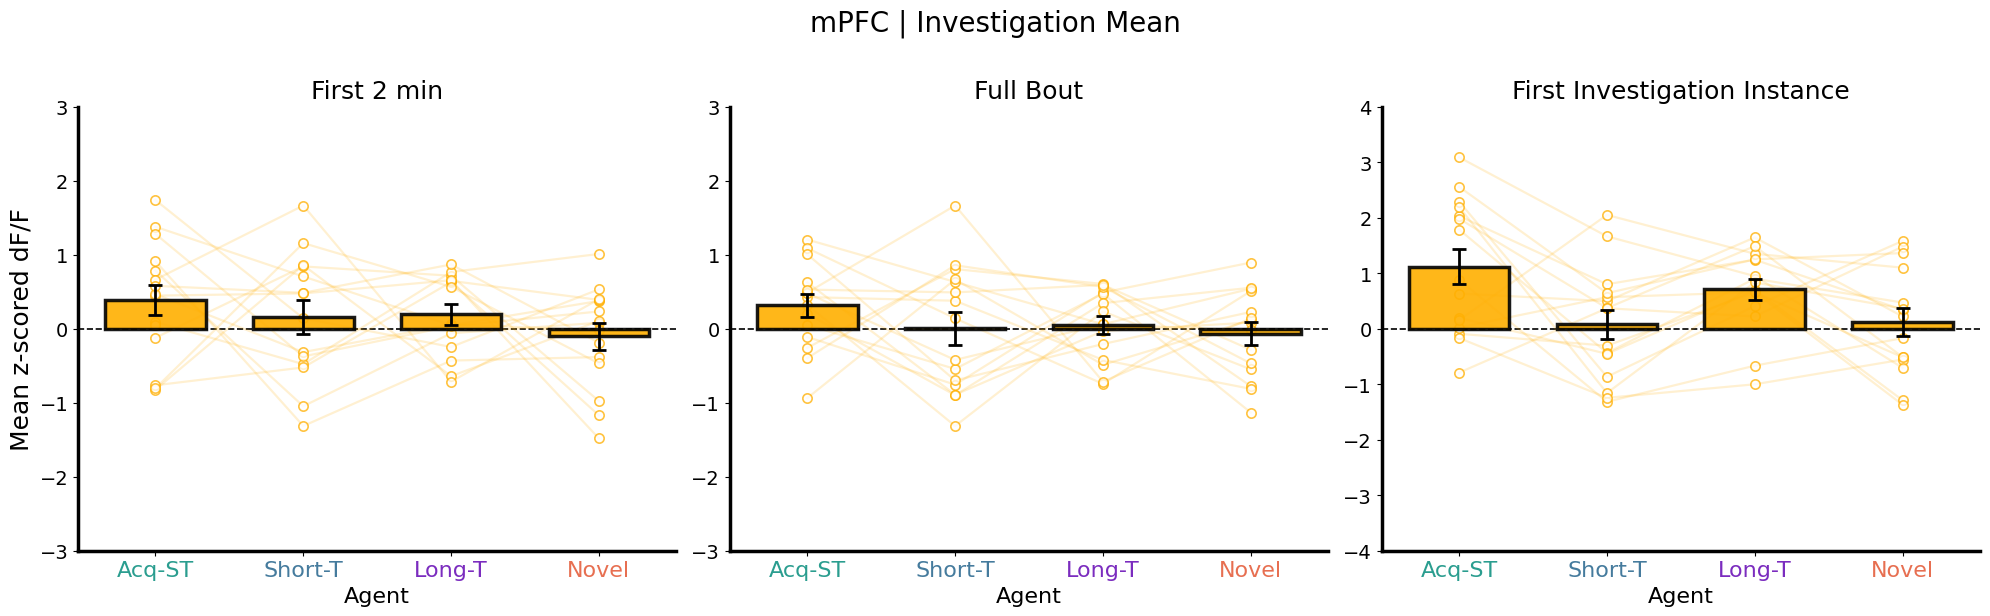

In [6]:
for region_name in SELECTED_REGIONS:
    for analysis_name in ANALYSIS_ORDER:
        plot_single_analysis(metadata_df, region_name, analysis_name, behavior_name='investigation', auto_ylim=True)

    plot_all_three_analyses(metadata_df, region_name, behavior_name='investigation', auto_ylim=True)

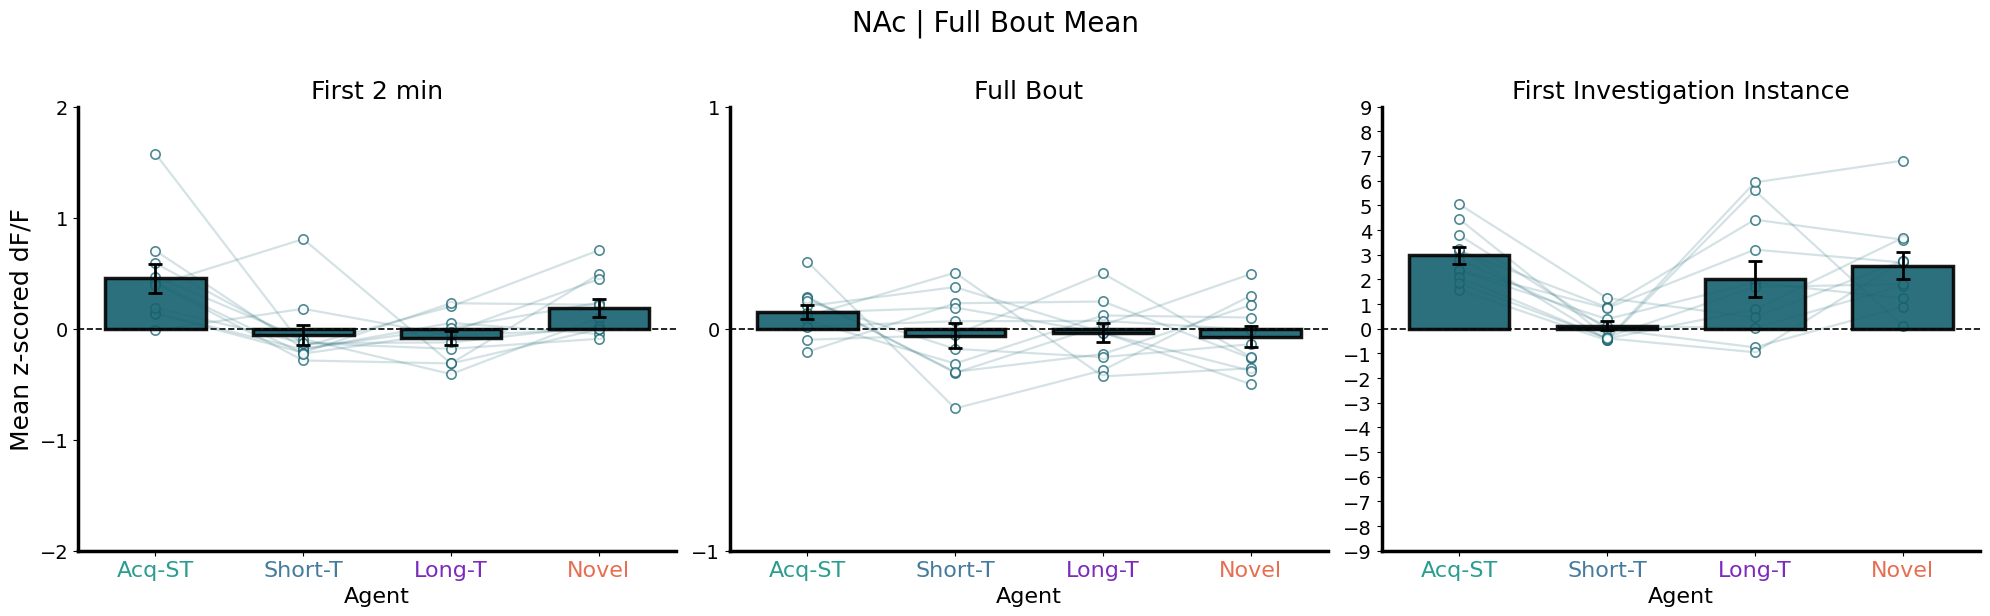

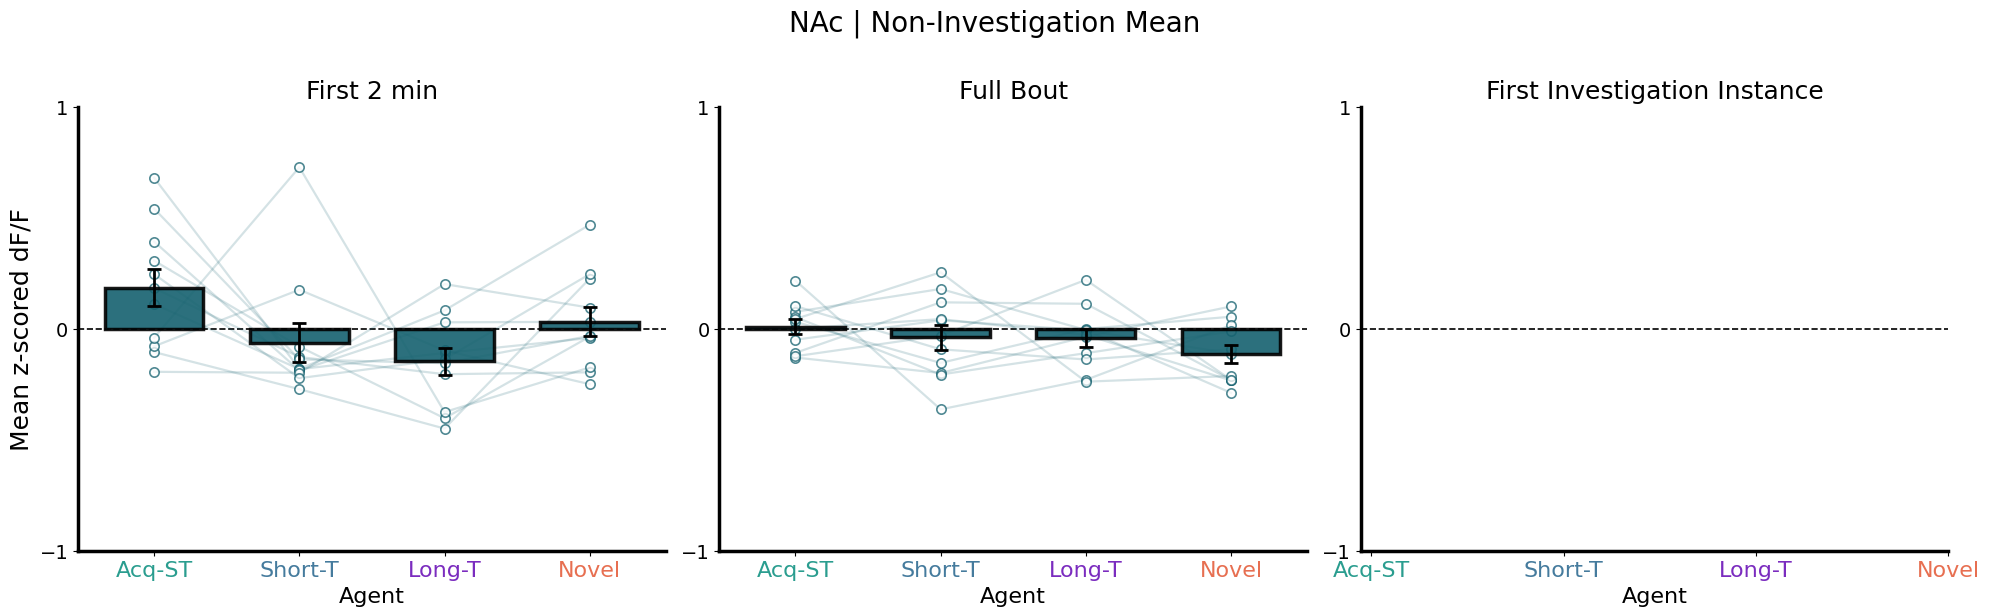

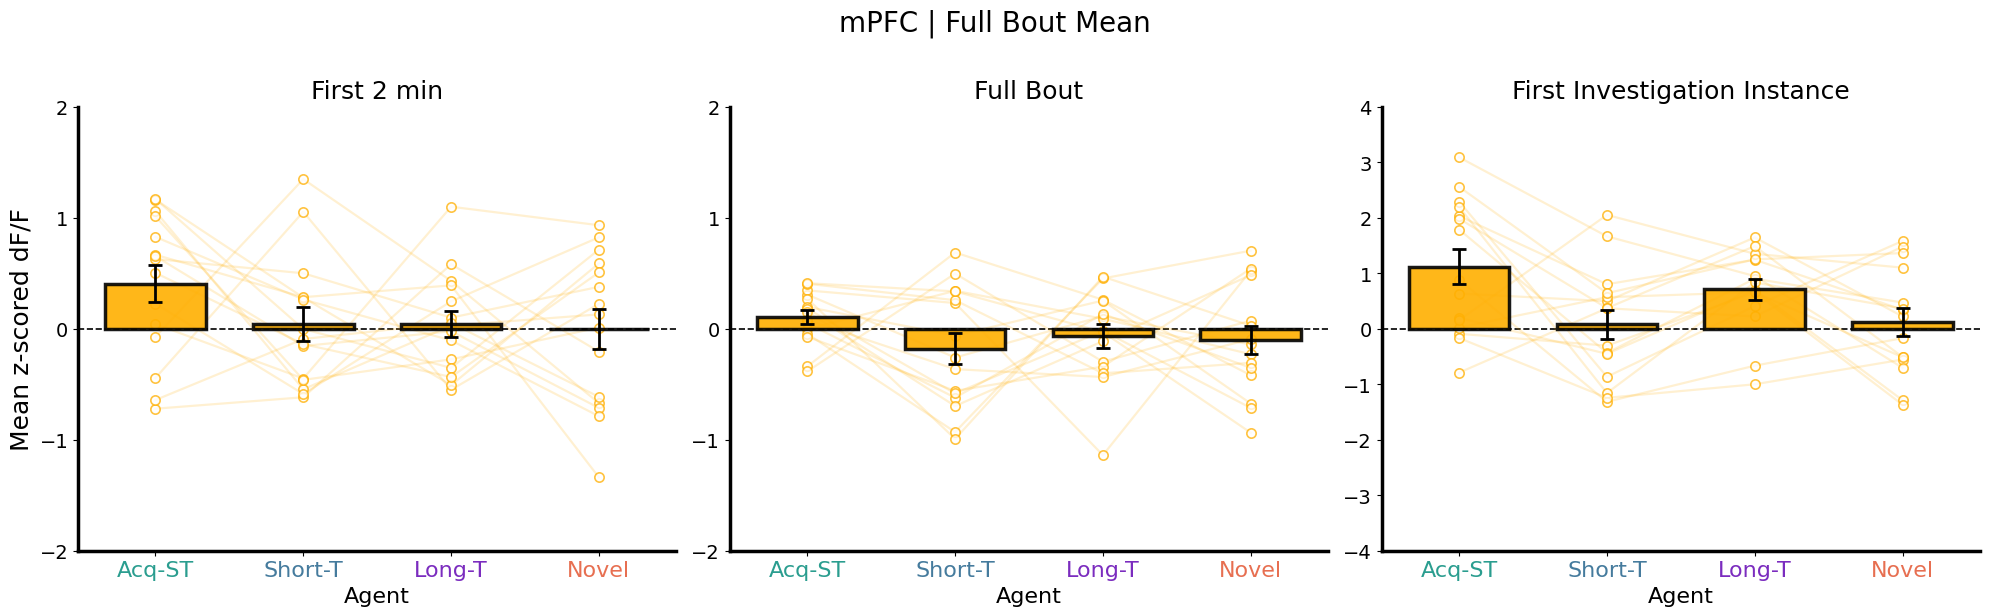

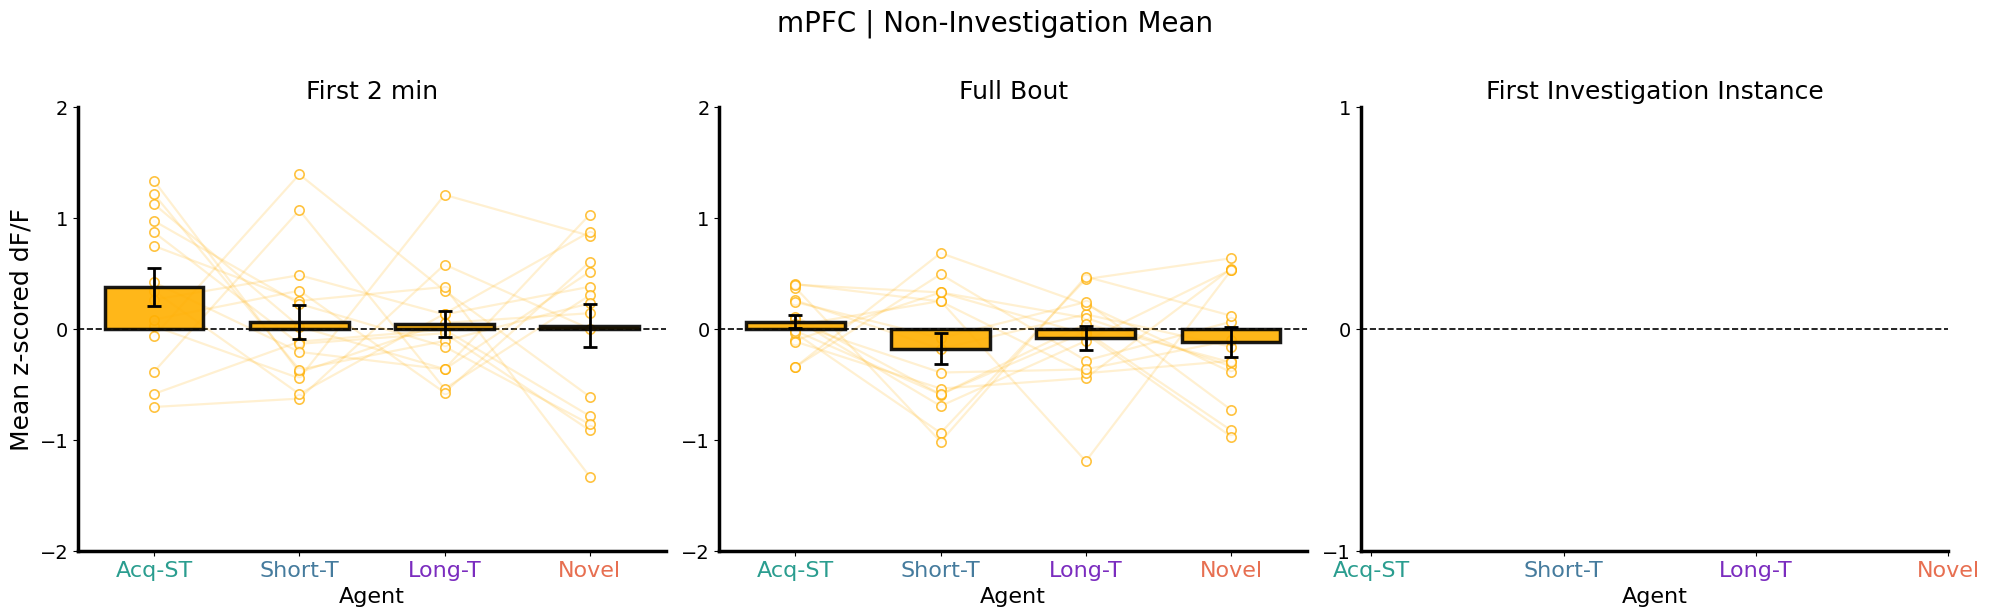

In [7]:
for region_name in SELECTED_REGIONS:
    plot_all_three_analyses(metadata_df, region_name, behavior_name='full_bout', auto_ylim=True)
    plot_all_three_analyses(metadata_df, region_name, behavior_name='non_investigation', auto_ylim=True)

In [8]:
x

NameError: name 'x' is not defined

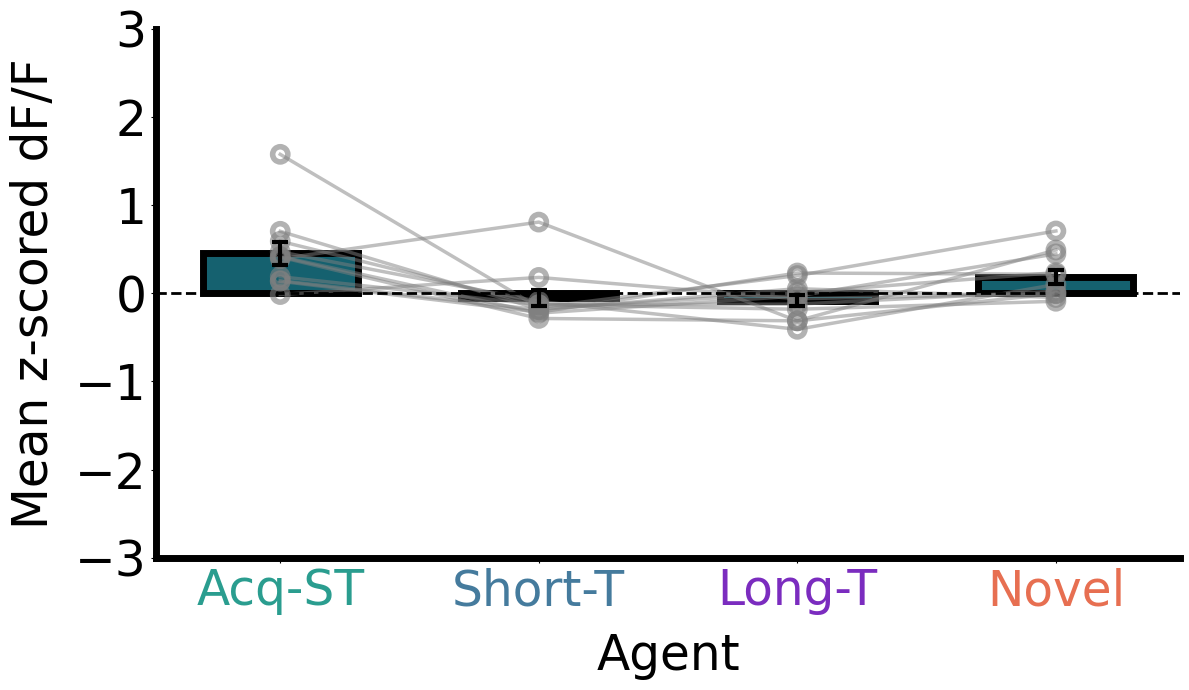


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  3.0027   0.0133   0.9053
 Short_Term-1 vs Long_Term-1 11  4.2173   0.0018   1.2716
     Short_Term-1 vs Novel-1 11  2.9014   0.0158   0.8748
 Short_Term-2 vs Long_Term-1 11  0.2288   0.8237   0.0690
     Short_Term-2 vs Novel-1 11 -1.6974   0.1205  -0.5118
      Long_Term-1 vs Novel-1 11 -3.3107   0.0079  -0.9982


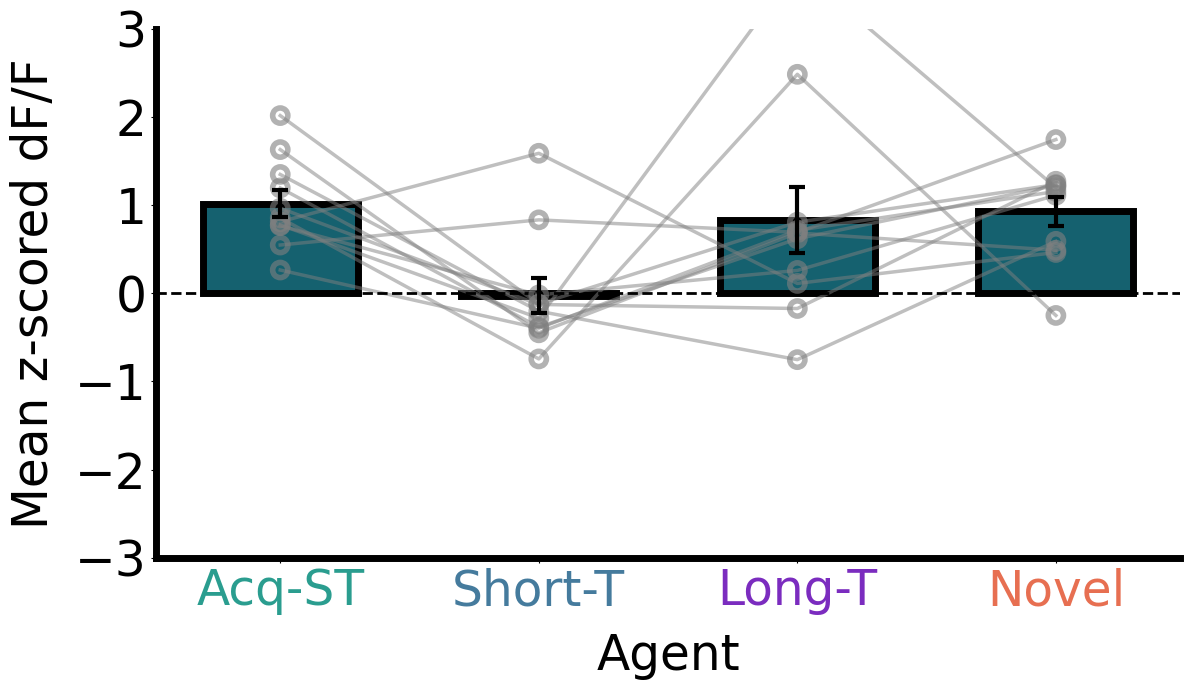


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  3.7719   0.0037   1.1373
 Short_Term-1 vs Long_Term-1 11  0.4313   0.6754   0.1300
     Short_Term-1 vs Novel-1 11  0.3576   0.7281   0.1078
 Short_Term-2 vs Long_Term-1 11 -1.7976   0.1025  -0.5420
     Short_Term-2 vs Novel-1 11 -4.0945   0.0022  -1.2345
      Long_Term-1 vs Novel-1 11 -0.2300   0.8227  -0.0693


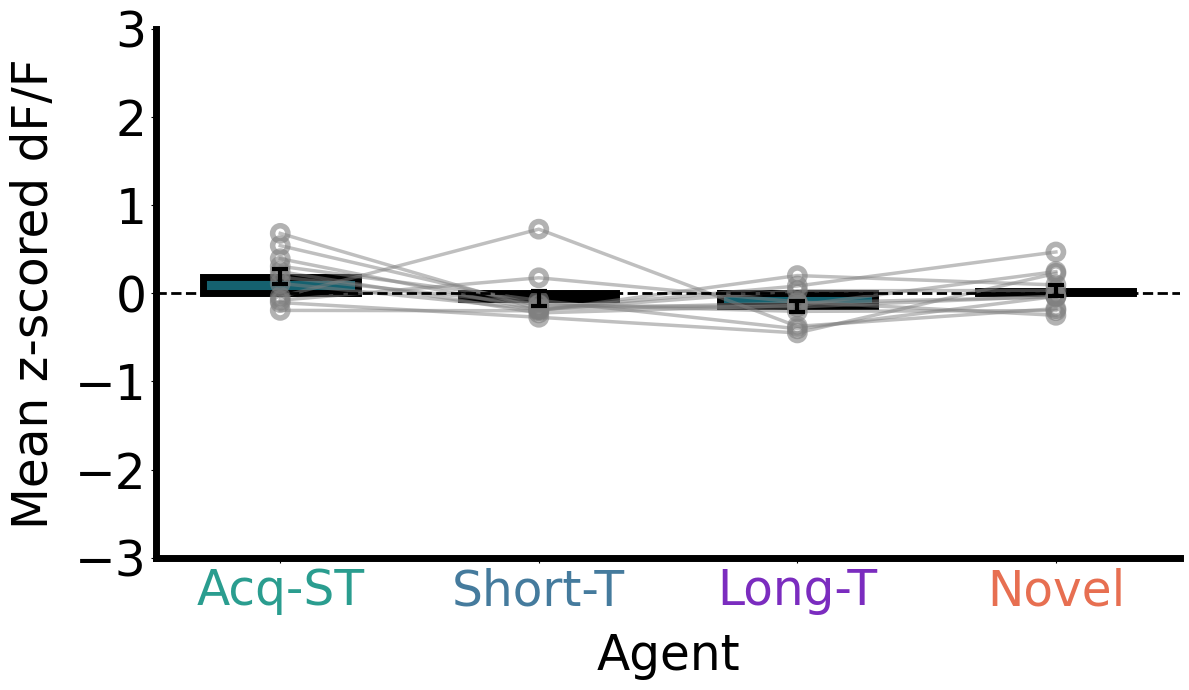


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 11  1.7958   0.1028   0.5414
 Short_Term-1 vs Long_Term-1 11  3.5049   0.0057   1.0568
     Short_Term-1 vs Novel-1 11  1.8589   0.0927   0.5605
 Short_Term-2 vs Long_Term-1 11  0.6953   0.5027   0.2096
     Short_Term-2 vs Novel-1 11 -0.6964   0.5021  -0.2100
      Long_Term-1 vs Novel-1 11 -2.3431   0.0411  -0.7065


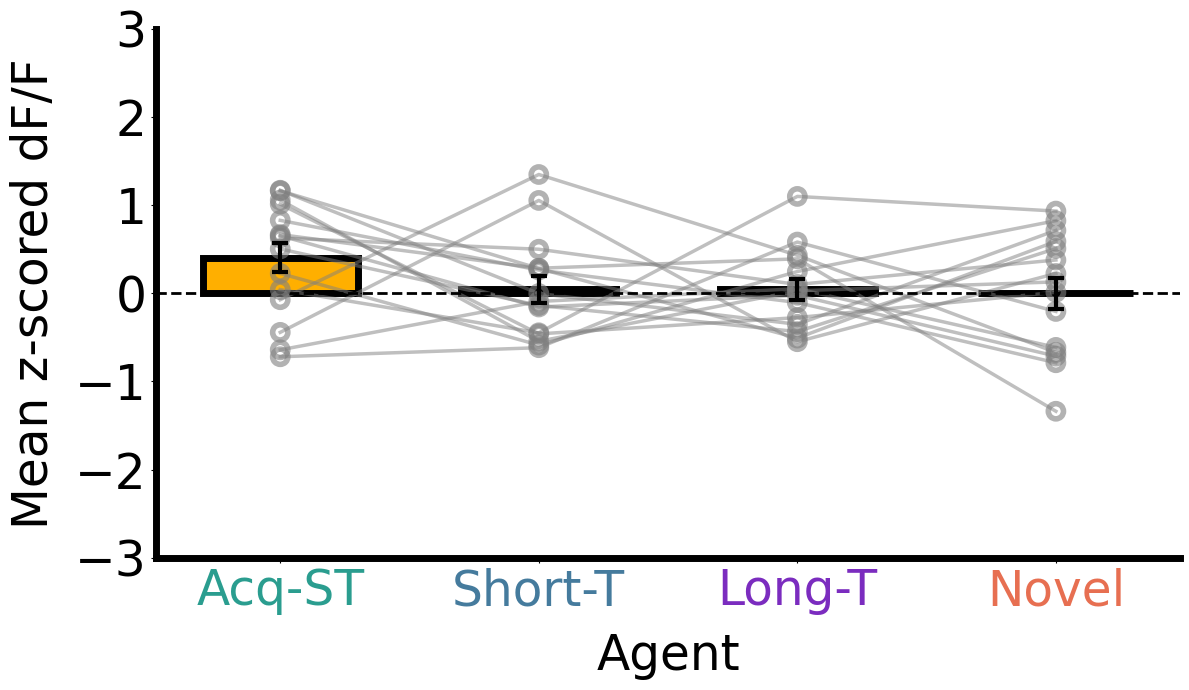


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 15  1.5038   0.1549   0.3883
 Short_Term-1 vs Long_Term-1 15  1.5021   0.1553   0.3878
     Short_Term-1 vs Novel-1 15  1.7981   0.0938   0.4643
 Short_Term-2 vs Long_Term-1 15  0.0006   0.9995   0.0002
     Short_Term-2 vs Novel-1 15  0.1767   0.8623   0.0456
      Long_Term-1 vs Novel-1 15  0.2091   0.8374   0.0540


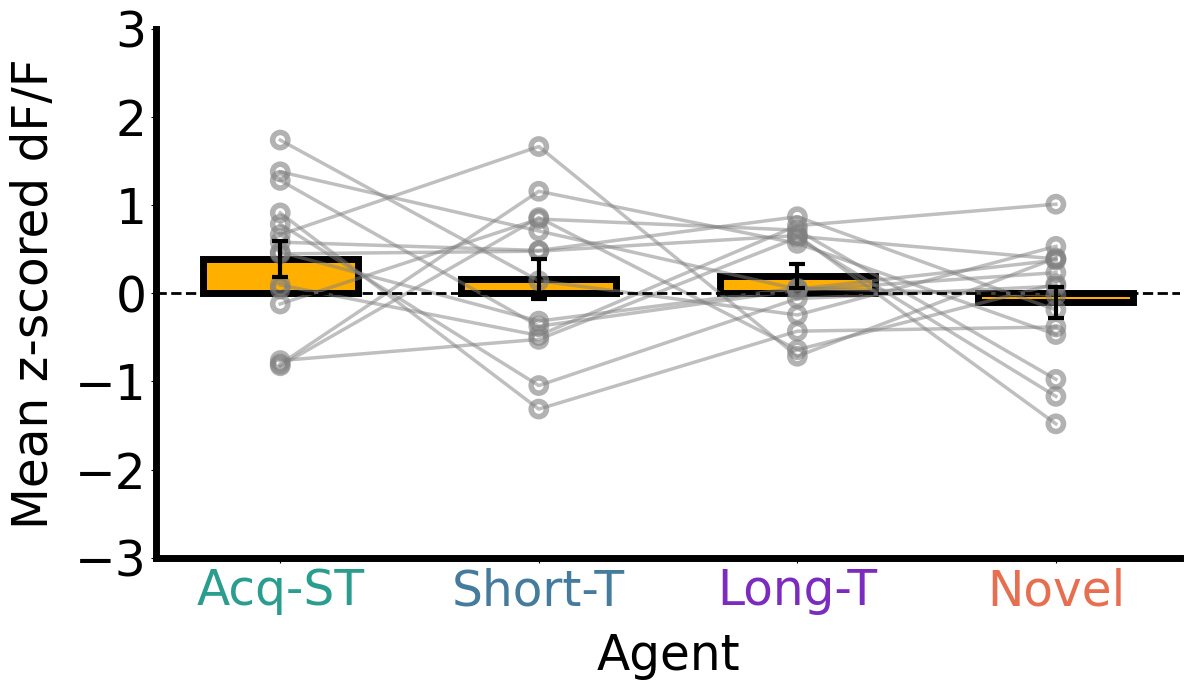


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 14  0.7169   0.4861   0.1916
 Short_Term-1 vs Long_Term-1 15  0.7042   0.4928   0.1818
     Short_Term-1 vs Novel-1 15  2.3341   0.0350   0.6027
 Short_Term-2 vs Long_Term-1 14  0.0082   0.9936   0.0022
     Short_Term-2 vs Novel-1 14  1.0001   0.3355   0.2673
      Long_Term-1 vs Novel-1 15  1.1410   0.2730   0.2946


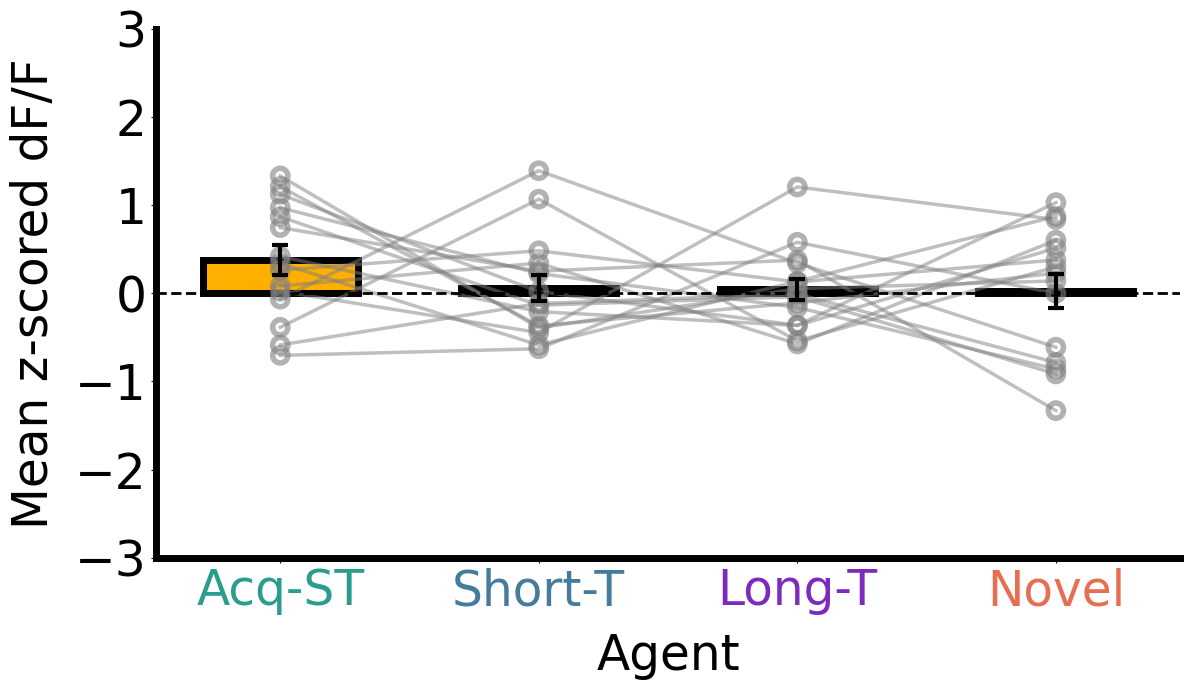


Paired t-test results:
                  comparison  n  t_stat  p_value  cohen_d
Short_Term-1 vs Short_Term-2 15  1.2664   0.2260   0.3270
 Short_Term-1 vs Long_Term-1 15  1.4580   0.1669   0.3764
     Short_Term-1 vs Novel-1 15  1.3534   0.1974   0.3495
 Short_Term-2 vs Long_Term-1 15  0.0725   0.9432   0.0187
     Short_Term-2 vs Novel-1 15  0.1212   0.9052   0.0313
      Long_Term-1 vs Novel-1 15  0.0737   0.9423   0.0190


,BrainRegion,Window,WindowLabel,comparison,n,t_stat,p_value,cohen_d,p_adj,reject,significance
0,NAc,full_bout,Full Bout Mean (First 2 min),Short_Term-1 vs Short_Term-2,11,3.002699,0.013282,0.905348,0.053129,False,ns
1,NAc,full_bout,Full Bout Mean (First 2 min),Short_Term-1 vs Long_Term-1,11,4.217319,0.001779,1.271570,0.010675,True,sig
2,NAc,full_bout,Full Bout Mean (First 2 min),Short_Term-1 vs Novel-1,11,2.901407,0.015795,0.874807,0.053129,False,ns
3,NAc,full_bout,Full Bout Mean (First 2 min),Short_Term-2 vs Long_Term-1,11,0.228754,0.823670,0.068972,0.823670,False,ns
4,NAc,full_bout,Full Bout Mean (First 2 min),Short_Term-2 vs Novel-1,11,-1.697382,0.120475,-0.511780,0.240949,False,ns
5,NAc,full_bout,Full Bout Mean (First 2 min),Long_Term-1 vs Novel-1,11,-3.310695,0.007870,-0.998212,0.039350,True,sig
6,NAc,investigation,Investigation Mean (First 2 min),Short_Term-1 vs Short_Term-2,11,3.771907,0.003650,1.137273,0.018251,True,sig
7,NAc,investigation,Investigation Mean (First 2 min),Short_Term-1 vs Long_Term-1,11,0.431326,0.675382,0.130050,1.000000,False,ns
8,NAc,investigation,Investigation Mean (First 2 min),Short_Term-1 vs Novel-1,11,0.357566,0.728100,0.107810,1.000000,False,ns
9,NAc,investigation,Investigation Mean (First 2 min),Short_Term-2 vs Long_Term-1,11,-1.797581,0.102455,-0.541991,0.409821,False,ns


In [ ]:
plot_results = {}
paired_stats_frames = []

for region_name in SELECTED_REGIONS:
    region_dir = OUTPUT_DIR / region_name
    region_dir.mkdir(parents=True, exist_ok=True)
    region_df = metadata_df[metadata_df['BrainRegion'] == region_name].copy()

    for window_name in WINDOW_ORDER:
        save_base = region_dir / f'{region_name}_{window_name}_{SIGNAL_NAME}_2min'
        pivot_df, stats_df = plot_behavior_across_bouts_no_identities(
            metadata_df=region_df,
            y_col=SIGNAL_COLUMN,
            behavior=window_name,
            title='',
            xlabel='Agent',
            ylabel='Mean z-scored dF/F',
            custom_xtick_labels=XTICK_LABELS,
            custom_xtick_colors=XTICK_COLORS,
            ylim=REGION_CONFIGS[region_name]['ylim'],
            bar_color=REGION_CONFIGS[region_name]['color'],
            yticks_increment=YTICKS_INCREMENT,
            figsize=(12, 7),
            pad_inches=0.1,
            save=True,
            save_name=str(save_base) + '.png',
            save_stats=str(save_base) + '_paired_ttests.csv',
        )

        stats_df = stats_df.copy()
        stats_df.insert(0, 'BrainRegion', region_name)
        stats_df.insert(1, 'Window', window_name)
        stats_df.insert(2, 'WindowLabel', WINDOW_LABELS[window_name])
        stats_df = holm_correct_stats(stats_df)
        stats_df.to_csv(str(save_base) + '_paired_ttests_holm.csv', index=False)

        plot_results[(region_name, window_name)] = {
            'pivot_df': pivot_df,
            'stats_df': stats_df,
        }
        paired_stats_frames.append(stats_df)

all_plot_stats_df = pd.concat(paired_stats_frames, ignore_index=True)
all_plot_stats_df.to_csv(OUTPUT_DIR / f'{SIGNAL_NAME}_paired_ttests_all_plots_2min.csv', index=False)
all_plot_stats_df.head(18)

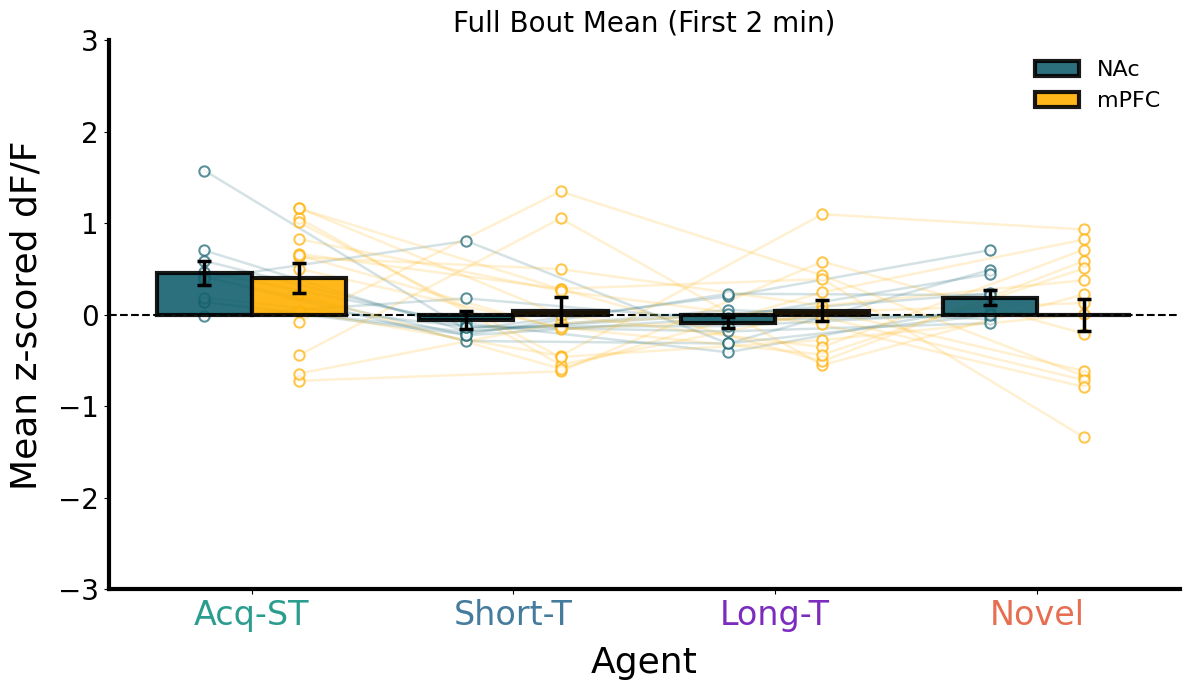

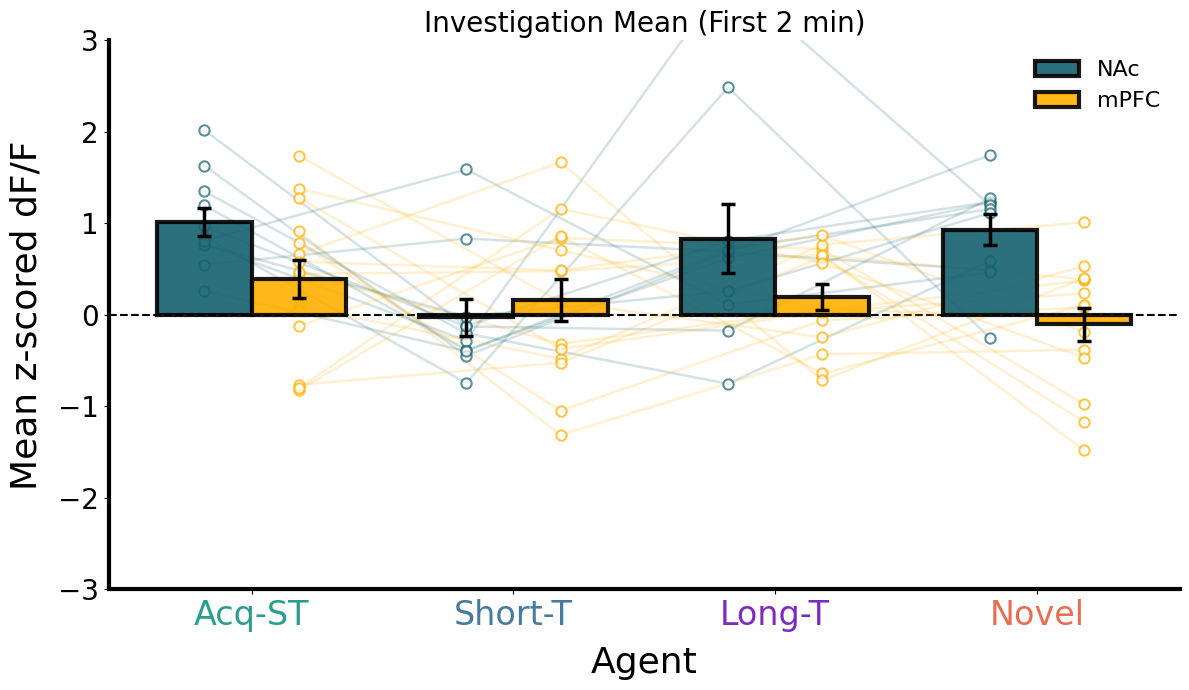

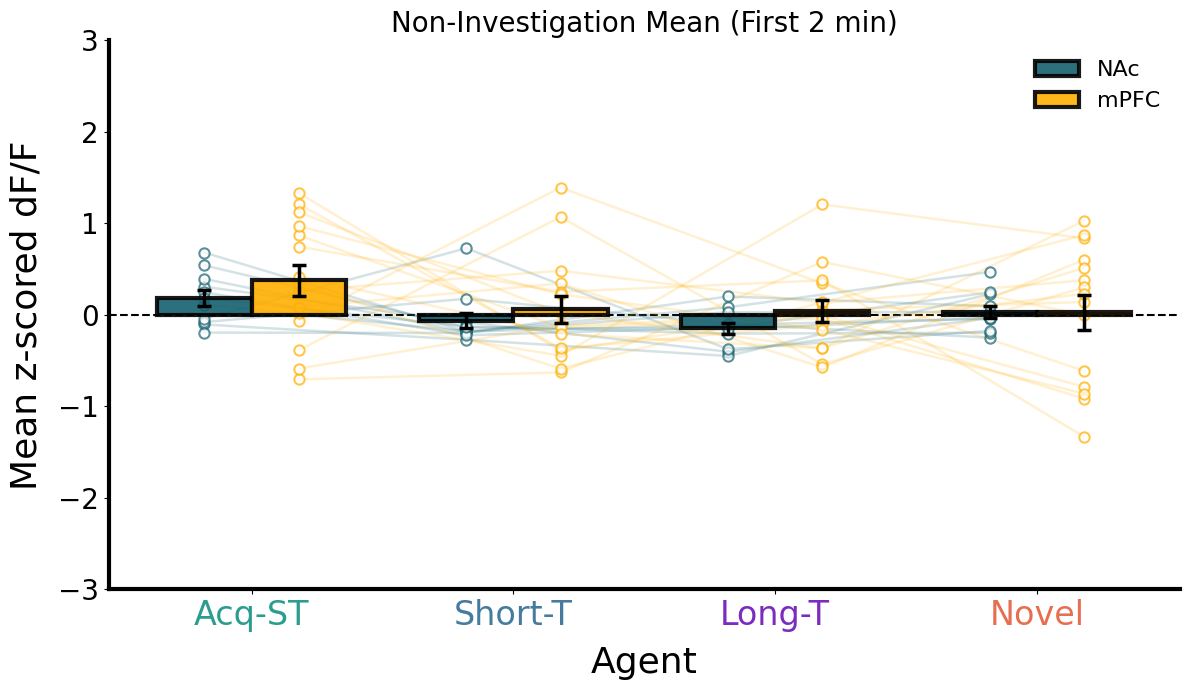

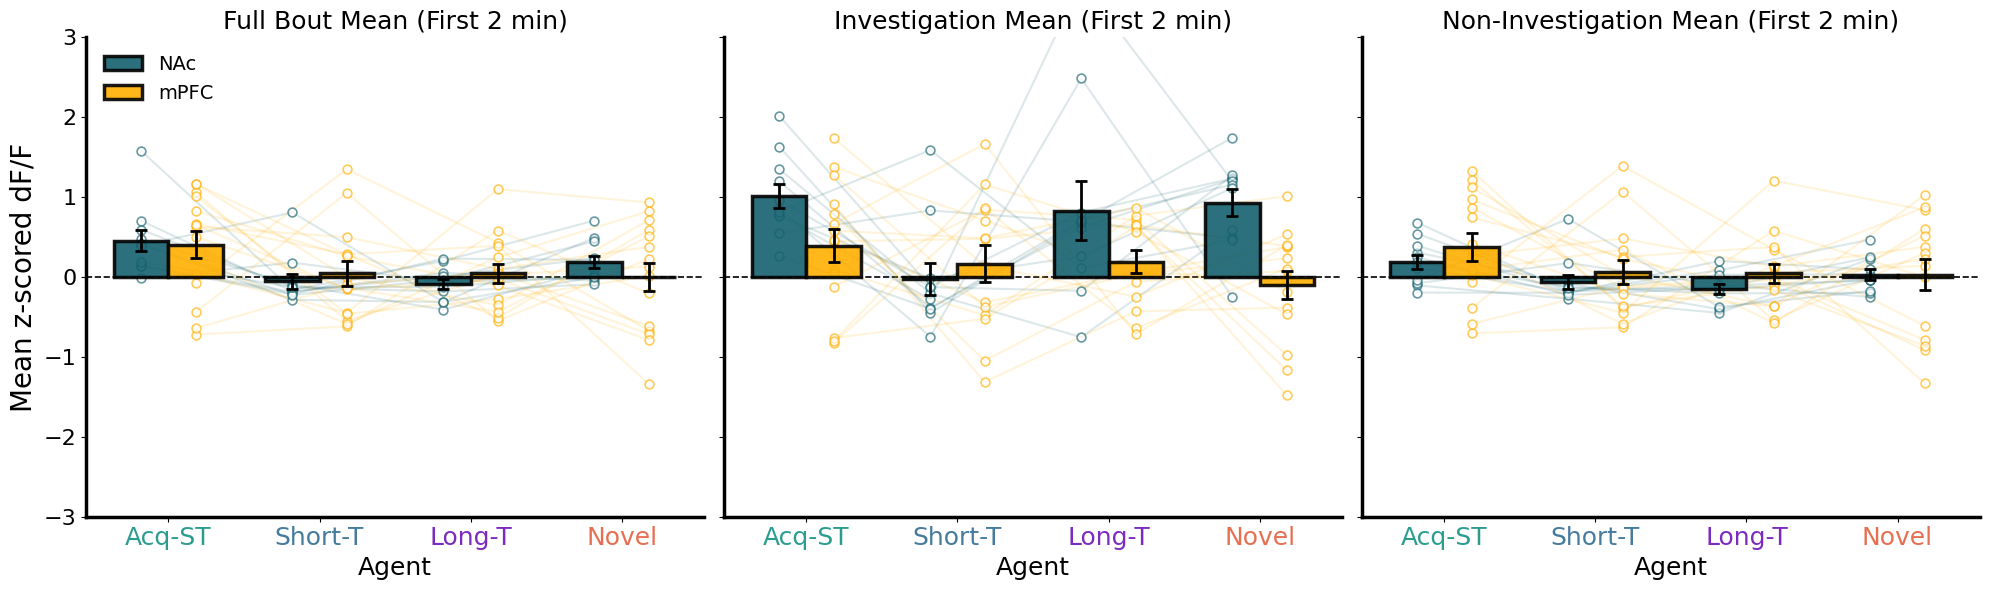

In [ ]:
comparison_dir = OUTPUT_DIR / 'comparison'
comparison_dir.mkdir(parents=True, exist_ok=True)

for window_name in WINDOW_ORDER:
    plot_region_comparison(
        metadata_df,
        window_name=window_name,
        save_name=comparison_dir / f'{window_name}_{SIGNAL_NAME}_2min_region_comparison.png',
    )

plot_all_region_comparisons(
    metadata_df,
    save_name=comparison_dir / f'all_windows_{SIGNAL_NAME}_2min_region_comparison.png',
)

In [ ]:
within_bout_window_stats = pd.concat(
    [run_within_bout_window_stats(metadata_df, region_name) for region_name in SELECTED_REGIONS],
    ignore_index=True,
)
within_bout_window_stats.to_csv(OUTPUT_DIR / f'{SIGNAL_NAME}_within_bout_window_paired_ttests_2min.csv', index=False)

summary_df = (
    metadata_df.groupby(['BrainRegion', 'Behavior', 'Bout'], observed=True)[SIGNAL_COLUMN]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
summary_df['sem'] = summary_df['std'] / np.sqrt(summary_df['count'].clip(lower=1))
summary_df.to_csv(OUTPUT_DIR / f'{SIGNAL_NAME}_summary_by_region_window_bout_2min.csv', index=False)
summary_df

,BrainRegion,Behavior,Bout,mean,std,count,sem
0,NAc,full_bout,Short_Term-1,0.456081,0.428662,11,0.129247
1,NAc,full_bout,Short_Term-2,-0.055560,0.310501,11,0.093620
2,NAc,full_bout,Long_Term-1,-0.085372,0.207721,11,0.062630
3,NAc,full_bout,Novel-1,0.188845,0.259386,11,0.078208
4,NAc,investigation,Short_Term-1,1.016698,0.499786,11,0.150691
5,NAc,investigation,Short_Term-2,-0.027457,0.665190,11,0.200562
6,NAc,investigation,Long_Term-1,0.831832,1.242101,11,0.374508
7,NAc,investigation,Novel-1,0.930560,0.551479,11,0.166277
8,NAc,non_investigation,Short_Term-1,0.185806,0.280631,11,0.084613
9,NAc,non_investigation,Short_Term-2,-0.062151,0.286969,11,0.086524


Outputs are saved to `Home_Cage/hc_bout_mean_da_2min_outputs/` with per-region plots, pooled comparison plots, and CSV summaries.